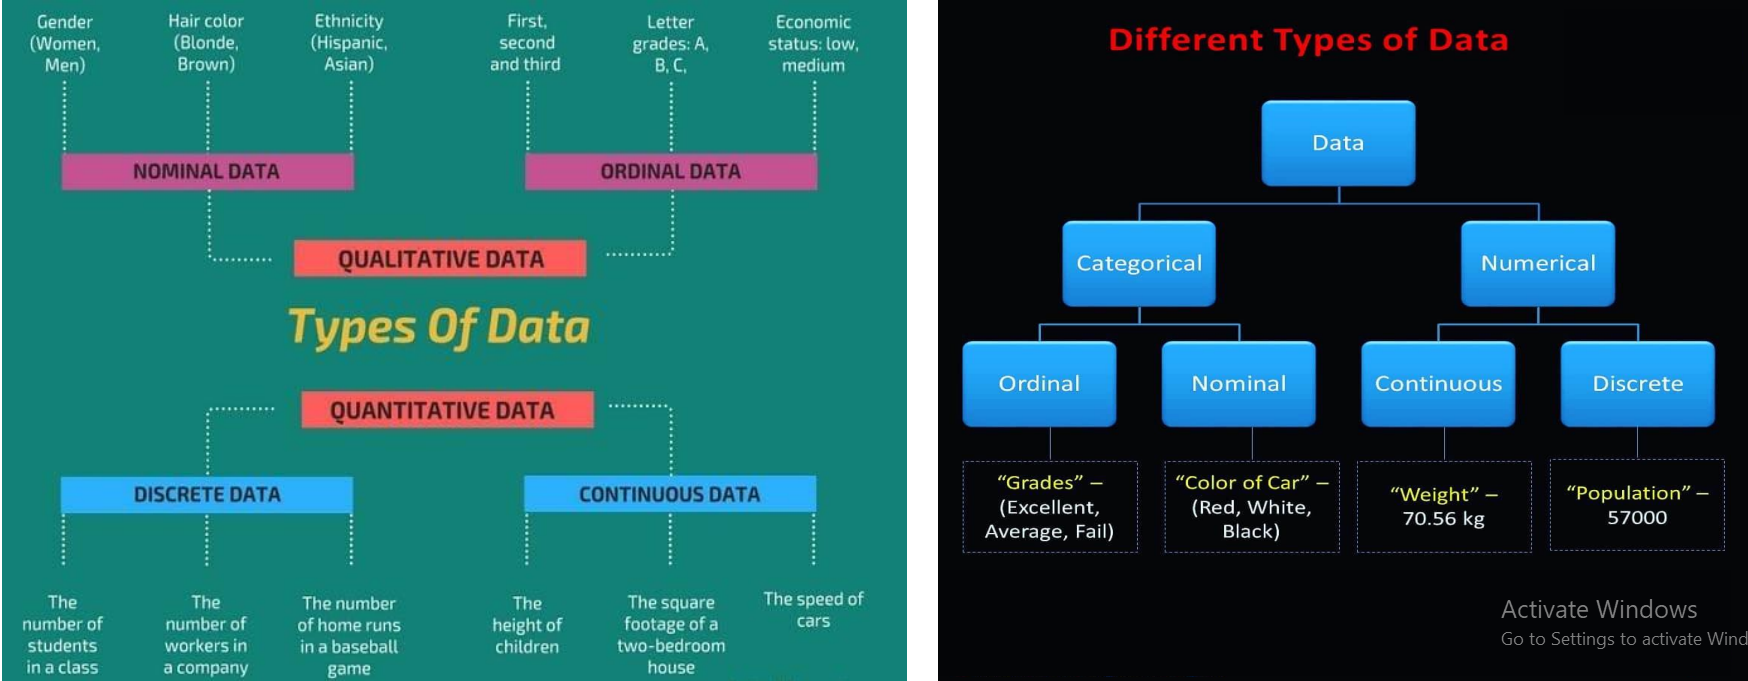

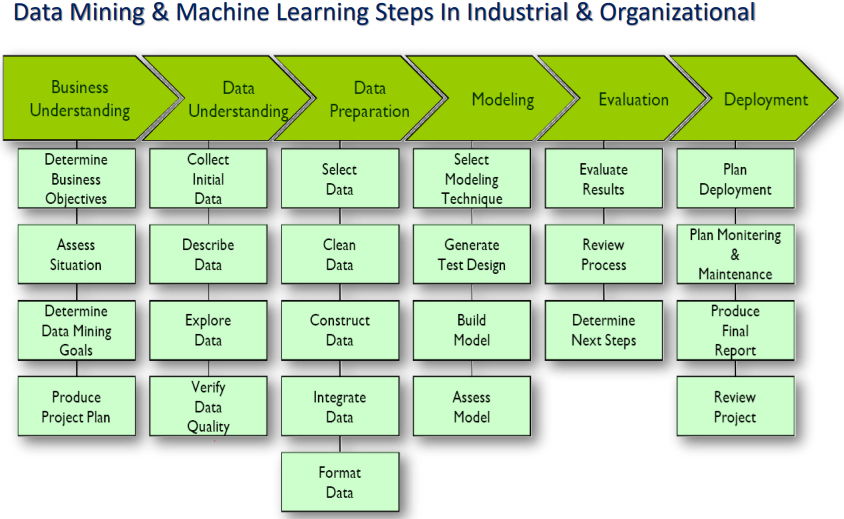

### 5 steps in preprocessing that is a must
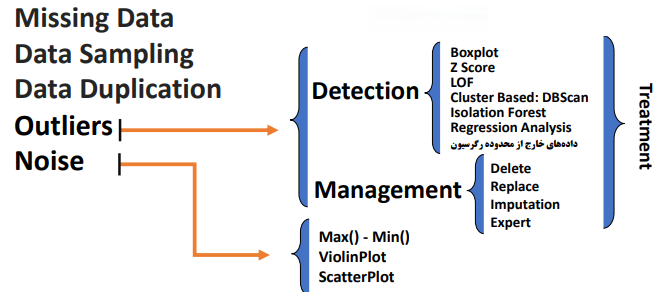

# Handling Missing Data

### Missing Data Replacement Scenarios:
1. **Replacing with Mean or Median** – Suitable for non-biased variables.
2. **Replacing with Mode** – Useful for categorical variables.
3. **Replacing using Nearby Values** – Forward fill or backward fill methods.
4. **Replacing with a Fixed Number** – Filling with a constant value.
5. **Replacing with Zero** – Suitable when zero has meaning in the context.
6. **Removing Observations** – Discarding rows with missing values.
7. **Removing Features** – Removing columns when more than half of the values are missing.

### Missing Data Imputation Scenarios:
1. **Using K-Nearest Neighbors (KNN)** – Imputing based on similar observations.
2. **Using Regression Models** – Predicting missing values using linear regression.
3. **Using Logistic Regression** – For categorical variables.
4. **Using Time Series Techniques** – Imputing missing values based on trends in time-series data.

## KNN Imputer

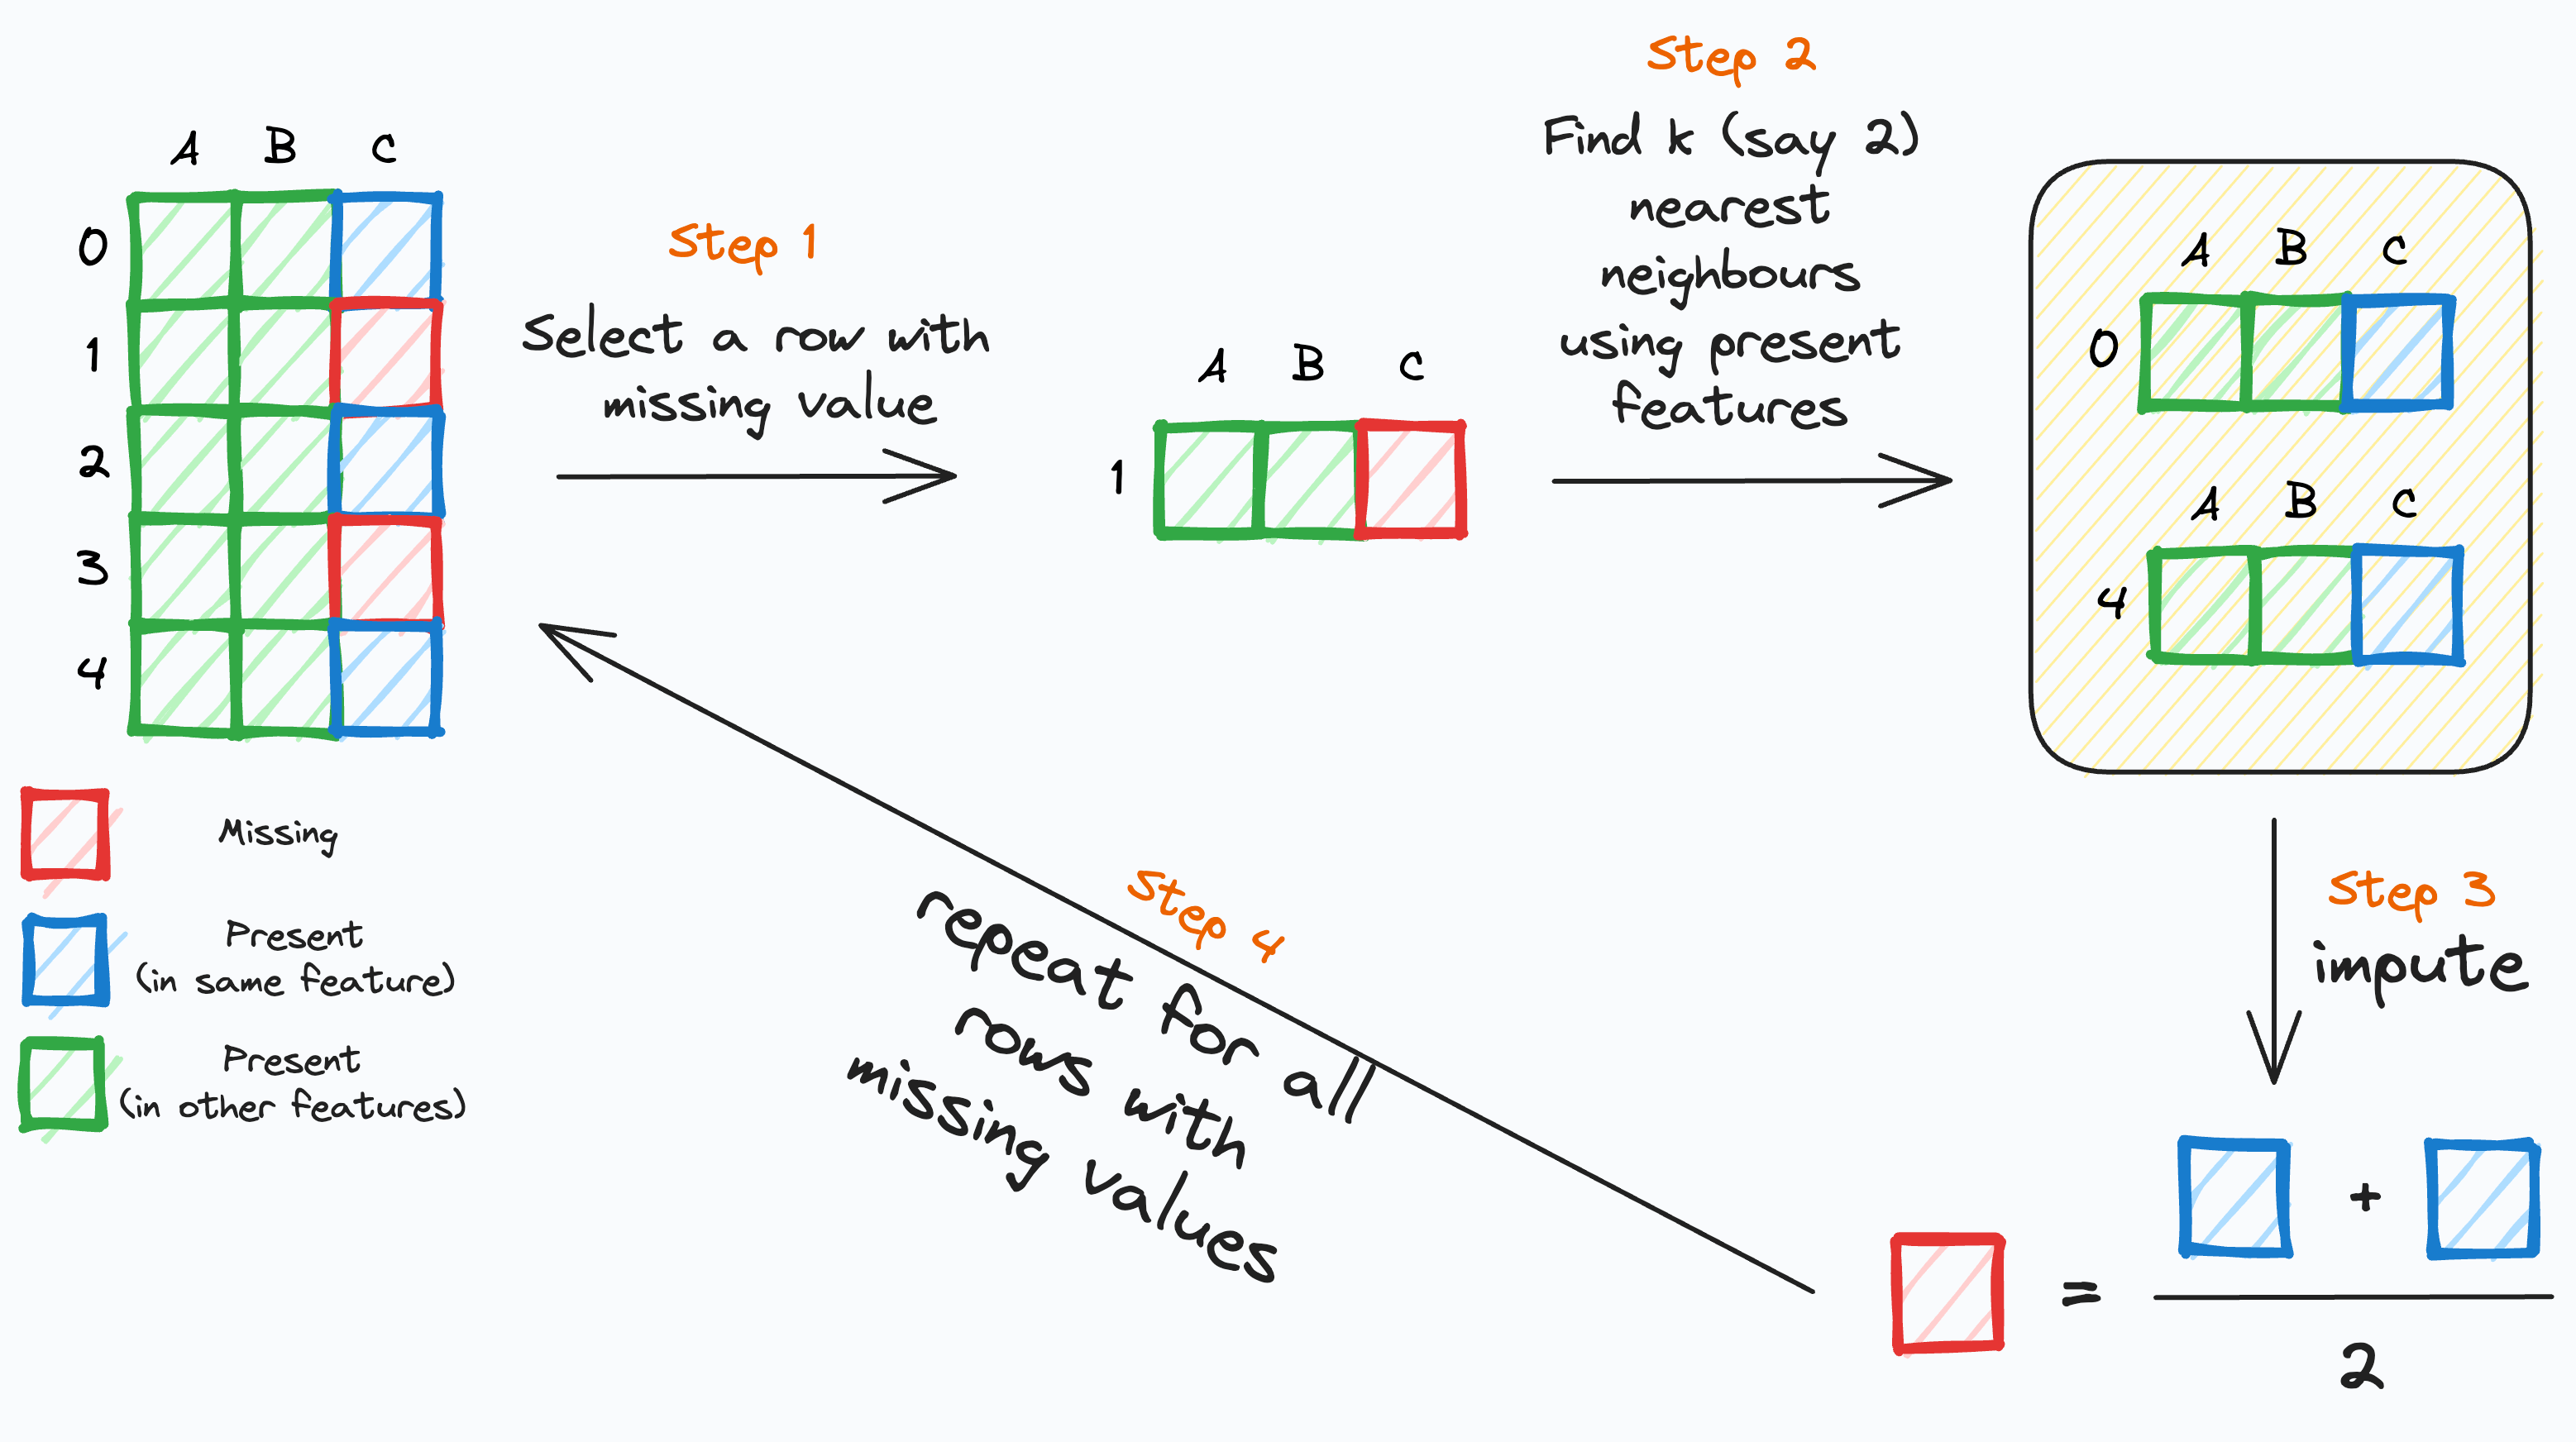

The **K-Nearest Neighbors (KNN) Imputer** is a data imputation technique that fills in missing values in a dataset using the k-nearest neighbors algorithm. Here's a step-by-step explanation with the mathematical principles involved:

---

### **Step 1: Identify Missing Values**
Let the dataset be $ X $, which is an $n \times m $ matrix, where:
- \( n \) is the number of samples (rows),
- \( m \) is the number of features (columns).

Assume a missing value $ x_{ij} $ exists in row $ i $, column $ j $.

---

### **Step 2: Calculate Pairwise Distances**
To find the nearest neighbors of the row $i $, we calculate the distance between $ X[i, :] $ (the row containing the missing value) and every other row $ X[l, :] $ that does not have a missing value in column $ j $. Common distance metrics include:

1. **Euclidean Distance**:
   $
   d(i, l) = \sqrt{\sum_{k \in F} \left( x_{ik} - x_{lk} \right)^2}
   $
   Here:
   - \( F \) is the set of indices of features (columns) where both rows \( i \) and \( l \) have values.
   - $ x_{ik} $ and $ x_{lk} $ are feature values for rows \( i \) and \( l \), respectively.

2. **Other Distance Metrics**:
   - **Manhattan Distance**: $ d(i, l) = \sum_{k \in F} \left| x_{ik} - x_{lk} \right| $
   - **Cosine Similarity**: Use cosine distance $ d(i, l) = 1 - \text{cosine similarity} $.

---

### **Step 3: Find the k-Nearest Neighbors**
Sort all distances $ d(i, l) $ in ascending order and select the \( k \) rows with the smallest distances. These are the "k-nearest neighbors."

---

### **Step 4: Impute the Missing Value**
The missing value $ x_{ij} $ is filled based on the values of the \( k \)-nearest neighbors in the same column \( j \). Common aggregation methods include:

1. **Mean Imputation**:
   $
   x_{ij} = \frac{1}{k} \sum_{l \in \text{kNN}} x_{lj}
   $
   Here:
   - \( x_{lj} \) is the value of column \( j \) in the \( l \)-th nearest neighbor.
   - \( \text{kNN} \) represents the indices of the \( k \)-nearest neighbors.

2. **Median Imputation**:
   $
   x_{ij} = \text{median}\left( \{ x_{lj} \ | \ l \in \text{kNN} \} \right)
   $

3. **Weighted Mean Imputation**:
   If distances are used as weights, closer neighbors contribute more:
   $
   x_{ij} = \frac{\sum_{l \in \text{kNN}} \frac{x_{lj}}{d(i, l)}}{\sum_{l \in \text{kNN}} \frac{1}{d(i, l)}}
   $
   Where \( d(i, l) \) is the distance between rows \( i \) and \( l \).

---

### **Step 5: Repeat for All Missing Values**
Apply the same procedure for all missing values in the dataset. This step-by-step computation ensures that all missing entries are imputed based on their respective nearest neighbors.

---

### Example Walkthrough
Suppose:
- Dataset $ X = \begin{bmatrix} 1 & 2 \\ 3 & ? \\ 5 & 6 \end{bmatrix} $,
- Missing value is $ x_{21} $,
- \( k = 2 \).

**Step 1**: Identify missing \( x_{21} \).

**Step 2**: Compute distances:
$
d(2, 1) = \sqrt{(3-1)^2} = 2, \quad d(2, 3) = \sqrt{(3-5)^2} = 2.
$

**Step 3**: Nearest neighbors are rows 1 and 3.

**Step 4**: Impute $ x_{21} $ using the mean of neighbors:
$
x_{21} = \frac{1 + 5}{2} = 3.
$

Result:
$
X = \begin{bmatrix} 1 & 2 \\ 3 & 3 \\ 5 & 6 \end{bmatrix}.
$

This illustrates how KNN Imputer works step by step with distances and aggregation methods.

> - Using KNN imputation with label-encoded data works reasonably well when the categorical data is ordinal (i.e., there’s a meaningful order between categories, like ‘Low’, ‘Medium’, ‘High’).
> - For nominal data (categories without a meaningful order), this approach can lead to suboptimal results because the imputer may infer incorrect relationships based on the encoded integers.

In [1]:
import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer

In [2]:
# Sample data with missing values
data = {
    'Feature_1': [1, 2, np.nan, 4, 5],
    'Feature_2': [5, np.nan, 3, 8, 10],
    'Feature_3': [np.nan, 15, 13, 12, 11]
}

In [4]:
df = pd.DataFrame(data)

print("Original Data with Missing Values:")
df

Original Data with Missing Values:


,Feature_1,Feature_2,Feature_3
0,1.0,5.0,NaN
1,2.0,NaN,15.0
2,NaN,3.0,13.0
3,4.0,8.0,12.0
4,5.0,10.0,11.0


In [5]:
# Initialize KNN Imputer with k=2 (n_neighbors=2)
imputer = KNNImputer(n_neighbors=2)

# Apply the imputer to the data
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
print("\nData after KNN Imputation:")
df_imputed


Data after KNN Imputation:


,Feature_1,Feature_2,Feature_3
0,1.0,5.0,14.0
1,2.0,4.0,15.0
2,1.5,3.0,13.0
3,4.0,8.0,12.0
4,5.0,10.0,11.0


## Logistic Regression for nominal data
> 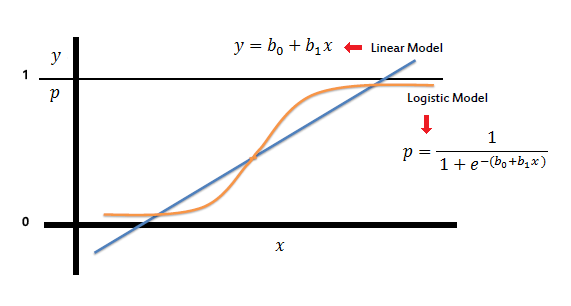

> Logistic Regression is a classification algorithm used when the response variable is categorical. It aims to find a relationship between features and the probability of a certain outcome. 
>> For example, predicting if a student passes or fails an exam based on study hours is Binomial Logistic Regression. Multinomial Logistic Regression is for situations with three or more possible outcomes.

Logistic regression unlike linear regression, which can predict values beyond the 0 to 1 range, logistic regression employs the logistic (sigmoid) function to model probabilities, ensuring outputs remain within this interval. 

**Key Concepts:**

- **Logit Function:** This function models the relationship between the independent variables and the log-odds of the dependent binary outcome. The log-odds represent the natural logarithm of the odds of the outcome occurring. 
> 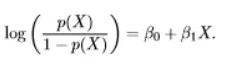
- **Sigmoid Function:** The inverse of the logit function, the sigmoid function maps any real-valued number into the (0, 1) interval, making it suitable for probability estimation. 
> 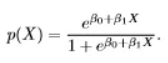
- **Maximum Likelihood Estimation (MLE):** Unlike linear regression, which uses Ordinary Least Squares (OLS) for parameter estimation, logistic regression relies on MLE to find the set of parameters that maximize the likelihood of observing the given data. 
> 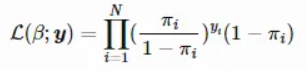

**Pros of Logistic Regression:**

- Simplicity and efficiency in implementation.

- Low variance, leading to consistent predictions across different datasets.

- Provides probability scores for observations, offering insights into prediction confidence.

**Cons of Logistic Regression:**

- Assumes a linear relationship between independent variables and the log-odds of the outcome, which may not hold in all cases.

- Less effective when the decision boundary between classes is complex or non-linear.

- Sensitive to outliers, which can disproportionately influence the model.

In summary, logistic regression is a fundamental and widely used method for binary classification tasks, offering a balance between simplicity and interpretability. However, its assumptions and limitations should be considered when applying it to complex datasets. 

### Maximum Likelihood Estimation (MLE) - A Simple Example

Let’s consider a simple example: **predicting whether a coin is biased or fair**.

---

### **Problem Setup**
You have a coin, and you want to estimate the probability of getting a "head" $( p )$.  
- $ p $ is unknown, but we assume it is constant for every flip.  
- Using MLE, we’ll estimate $ p $ based on observed data.

---

### **Data**  
You flip the coin 10 times, and the outcomes are:
```
H, T, H, H, T, H, T, H, H, H
```
Here:
- "H" represents heads (1), and "T" represents tails (0).
- Total flips $( n )$ = 10
- Number of heads $ \text{sum of outcomes} $ = 7

---

### **Likelihood Function**
The probability of getting heads or tails in a single flip follows a **Bernoulli distribution**:
$
P(\text{head}) = p, \quad P(\text{tail}) = 1 - p
$

For \( n \) independent flips, the likelihood of observing the data is:
$
L(p) = P(\text{data}|p) = p^k (1-p)^{n-k}
$
where:
- \( k \) = number of heads = 7
- \( n-k \) = number of tails = 3

So, the likelihood function becomes:
$
L(p) = p^7 (1-p)^3
$

---

### **Log-Likelihood Function**
To simplify calculations, take the natural logarithm of the likelihood:
$
\ell(p) = \ln(L(p)) = 7 \ln(p) + 3 \ln(1-p)
$

---

### **Maximizing the Log-Likelihood**
To find the value of \( p \) that maximizes $ \ell(p) $, take its derivative with respect to \( p \), set it to 0, and solve for \( p \):
$
\frac{d\ell(p)}{dp} = \frac{7}{p} - \frac{3}{1-p} = 0
$

Simplify:
$
\frac{7}{p} = \frac{3}{1-p}
$

Cross-multiply:
$
7(1-p) = 3p
$

Expand:
$
7 - 7p = 3p
$

Solve for \( p \):
$
7 = 10p \implies p = \frac{7}{10} = 0.7
$

---

### **Interpretation**
The MLE estimate for \( p \) is **0.7**. This means that, based on the observed data, the coin is likely biased, with a 70% chance of landing heads.

---

### **Key Takeaways**
1. **Likelihood Function:** Captures how likely the observed data is for different values of \( p \).
2. **Maximization:** MLE finds the value of \( p \) that makes the observed data most likely.
3. **Result:** The estimate \( p = 0.7 \) maximizes the likelihood of observing 7 heads out of 10 flips.

This simple example illustrates the core idea of MLE: estimating the parameter \( p \) by maximizing the likelihood of the observed data!

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Sample data with missing values in the 'Color' column
data = {
    'Color': ['Red', 'Blue', np.nan, 'Green', 'Red', 'Green', 'Blue', np.nan],
    'Shape': ['Circle', 'Square', 'Circle', 'Square', 'Circle', 'Square', 'Circle', 'Square'],
    'Size': [1, 2, 1, 2, 1, 2, 1, 2]
}
df = pd.DataFrame(data)

print("Original Data:")
df

Original Data:


,Color,Shape,Size
0,Red,Circle,1
1,Blue,Square,2
2,NaN,Circle,1
3,Green,Square,2
4,Red,Circle,1
5,Green,Square,2
6,Blue,Circle,1
7,NaN,Square,2


In [3]:
df.loc[df['Color'].notna()]

,Color,Shape,Size
0,Red,Circle,1
1,Blue,Square,2
3,Green,Square,2
4,Red,Circle,1
5,Green,Square,2
6,Blue,Circle,1


In [6]:
from sklearn.preprocessing import LabelEncoder

# Encode 'Shape' and 'Color' columns
encoder_shape = LabelEncoder()
df['Shape_encoded'] = encoder_shape.fit_transform(df['Shape'])

# Encode only non-missing values
encoder_color = LabelEncoder()
df.loc[df['Color'].notna(), 'Color_encoded'] = encoder_color.fit_transform(df['Color'].dropna())

In [7]:
df

,Color,Shape,Size,Shape_encoded,Color_encoded
0,Red,Circle,1,0,2.0
1,Blue,Square,2,1,0.0
2,NaN,Circle,1,0,NaN
3,Green,Square,2,1,1.0
4,Red,Circle,1,0,2.0
5,Green,Square,2,1,1.0
6,Blue,Circle,1,0,0.0
7,NaN,Square,2,1,NaN


In [8]:
# Separate data into known and missing
df_known = df[df['Color'].notna()]
df_missing = df[df['Color'].isna()]

X_known = df_known[['Shape_encoded', 'Size']]
y_known = df_known['Color_encoded']

X_missing = df_missing[['Shape_encoded', 'Size']]

In [9]:
# Train a logistic regression model on known data
model = LogisticRegression()
model.fit(X_known, y_known)

LogisticRegression()

In [12]:
# Predict missing values using the trained model
predictions = model.predict(X_missing)
predictions

array([2., 1.])

In [14]:
df_missing

,Color,Shape,Size,Shape_encoded,Color_encoded
2,NaN,Circle,1,0,NaN
7,NaN,Square,2,1,NaN


In [16]:
encoder_color.inverse_transform(predictions.astype(int))

array(['Red', 'Green'], dtype=object)

In [24]:
# Decode the predicted values back to original categories
df.loc[df['Color'].isna(), 'Color_imputed'] = encoder_color.inverse_transform(predictions.astype(int))
# df_missing['Color_imputed'] = encoder_color.inverse_transform(predictions.astype(int))

In [26]:
# Combine known and imputed data
df_combined = pd.concat([df_known, df_missing.sort_index()]).sort_index()
df_combined.loc[df['Color'].notna(), 'Color_imputed'] = df_combined.loc[df['Color'].notna(), 'Color']
print("\nData after Logistic Regression Imputation:")
print(df_combined[['Color', 'Shape', 'Size', 'Color_imputed']])


Data after Logistic Regression Imputation:
   Color   Shape  Size Color_imputed
0    Red  Circle     1           Red
1   Blue  Square     2          Blue
2    NaN  Circle     1           Red
3  Green  Square     2         Green
4    Red  Circle     1           Red
5  Green  Square     2         Green
6   Blue  Circle     1          Blue
7    NaN  Square     2         Green


# Outlier Detection

## **Local Outlier Factor (LOF)** for detecting local outliers in data.
- **Purpose**: LOF is used to identify outliers (anomalies) in datasets by comparing the local density of each point to the densities of its neighbors.
- **Concept**: 
  - If a point has a much lower density than its neighbors, it is likely an outlier.
  - LOF assigns a score to each point:
    - **LOF ≈ 1**: The point is on the border between inliers and outliers.
    - **LOF < 1**: The point is likely an inlier (normal).
    - **LOF > 1**: The point is likely an outlier (anomalous).
- **Key Metric**: Local Reachable Density (LRD) measures how isolated a point is compared to its neighbors.
>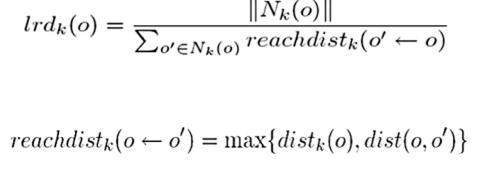
>> The formula defines how to compute the reachable distance and LRD for each point.

## how to calculate the **Local Outlier Factor (LOF)** for four points using a simple example. Here’s a breakdown of the example and steps:

---
### Summary of Steps:
1. Compute distances between all points.
2. Identify k-nearest neighbors for each point.
3. Calculate the reachability distance for each pair of points.
4. Compute the Local Reachable Density (LRD) for each point.
5. Use LRD values to calculate the Local Outlier Factor (LOF) for each point.
6. Interpret LOF values to determine which points are outliers.

Let's go through the **Local Reachable Density (LRD)** calculation step-by-step manually:

---

### **Step 1: List of points**
We have four points:
- **a(0, 0)**
- **b(1, 0)**
- **c(1, 1)**
- **d(3, 1)**

We assume **k = 2**, meaning we will use the 2 nearest neighbors for each point.

---

### **Step 2: Compute pairwise distances**
We calculate the Euclidean distance between each pair of points:

- **Distance between a and b**:
  $
  \text{dist}(a, b) = \sqrt{(1 - 0)^2 + (0 - 0)^2} = \sqrt{1} = 1
  $
- **Distance between a and c**:
  $
  \text{dist}(a, c) = \sqrt{(1 - 0)^2 + (1 - 0)^2} = \sqrt{1 + 1} = \sqrt{2} \approx 1.41
  $
- **Distance between a and d**:
  $
  \text{dist}(a, d) = \sqrt{(3 - 0)^2 + (1 - 0)^2} = \sqrt{9 + 1} = \sqrt{10} \approx 3.16
  $
- **Distance between b and c**:
  $
  \text{dist}(b, c) = \sqrt{(1 - 1)^2 + (1 - 0)^2} = \sqrt{0 + 1} = 1
  $
- **Distance between b and d**:
  $
  \text{dist}(b, d) = \sqrt{(3 - 1)^2 + (1 - 0)^2} = \sqrt{4 + 1} = \sqrt{5} \approx 2.24
  $
- **Distance between c and d**:
  $
  \text{dist}(c, d) = \sqrt{(3 - 1)^2 + (1 - 1)^2} = \sqrt{4 + 0} = 2
  $

---

### **Step 3: Find k-distances**
For each point, we find the **k-distance**, which is the distance to the 2nd nearest neighbor.

- **k-distance(a)**: The 2 nearest neighbors of **a** are **b** and **c**, with distances:
  $
  \text{dist}(a, b) = 1, \quad \text{dist}(a, c) \approx 1.41
  $
  The 2nd nearest neighbor is **c**, so:
  $
  k\text{-distance}(a) = 1.41
  $

- **k-distance(b)**: The 2 nearest neighbors of **b** are **a** and **c**, with distances:
  $
  \text{dist}(b, a) = 1, \quad \text{dist}(b, c) = 1
  $
  The 2nd nearest neighbor is **c**, so:
  $
  k\text{-distance}(b) = 1
  $

- **k-distance(c)**: The 2 nearest neighbors of **c** are **b** and **a**, with distances:
  $
  \text{dist}(c, b) = 1, \quad \text{dist}(c, a) \approx 1.41
  $
  The 2nd nearest neighbor is **a**, so:
  $
  k\text{-distance}(c) = 1.41
  $

- **k-distance(d)**: The 2 nearest neighbors of **d** are **c** and **b**, with distances:
  $
  \text{dist}(d, c) = 2, \quad \text{dist}(d, b) \approx 2.24
  $
  The 2nd nearest neighbor is **b**, so:
  $
  k\text{-distance}(d) = 2.24
  $

---

### **Step 4: Compute reachability distances**
For each pair of points, the **reachability distance** is:

$
\text{Reachability dist}(o, o') = \max \left( k\text{-dist}(o'), \text{dist}(o, o') \right)
$

Let's compute the reachability distances for each pair where **o'** is a neighbor of **o**:

#### **For point a**:
- **Reachability dist(a, b)**:
  $
  \text{Reachability dist}(a, b) = \max(k\text{-dist}(b), \text{dist}(a, b)) = \max(1, 1) = 1
  $
- **Reachability dist(a, c)**:
  $
  \text{Reachability dist}(a, c) = \max(k\text{-dist}(c), \text{dist}(a, c)) = \max(1.41, 1.41) = 1.41
  $

#### **For point b**:
- **Reachability dist(b, a)**:
  $
  \text{Reachability dist}(b, a) = \max(k\text{-dist}(a), \text{dist}(b, a)) = \max(1.41, 1) = 1.41
  $
- **Reachability dist(b, c)**:
  $
  \text{Reachability dist}(b, c) = \max(k\text{-dist}(c), \text{dist}(b, c)) = \max(1.41, 1) = 1.41
  $

#### **For point c**:
- **Reachability dist(c, b)**:
  $
  \text{Reachability dist}(c, b) = \max(k\text{-dist}(b), \text{dist}(c, b)) = \max(1, 1) = 1
  $
- **Reachability dist(c, a)**:
  $
  \text{Reachability dist}(c, a) = \max(k\text{-dist}(a), \text{dist}(c, a)) = \max(1.41, 1.41) = 1.41
  $

#### **For point d**:
- **Reachability dist(d, c)**:
  $
  \text{Reachability dist}(d, c) = \max(k\text{-dist}(c), \text{dist}(d, c)) = \max(1.41, 2) = 2
  $
- **Reachability dist(d, b)**:
  $
  \text{Reachability dist}(d, b) = \max(k\text{-dist}(b), \text{dist}(d, b)) = \max(1, 2.24) = 2.24
  $

---

### **Step 5: Compute Local Reachable Density (LRD)**

The **Local Reachable Density (LRD)** for a point **o** is:

$
\text{LRD}(o) = \frac{|N_k(o)|}{\sum_{o' \in N_k(o)} \text{Reachability dist}(o, o')}
$

Where **|N_k(o)|** is the number of neighbors (in this case, **2**).

#### **LRD for point a**:
$
\text{LRD}(a) = \frac{2}{1 + 1.41} = \frac{2}{2.41} \approx 0.83
$

#### **LRD for point b**:
$
\text{LRD}(b) = \frac{2}{1.41 + 1.41} = \frac{2}{2.82} \approx 0.71
$

#### **LRD for point c**:
$
\text{LRD}(c) = \frac{2}{1 + 1.41} = \frac{2}{2.41} \approx 0.83
$

#### **LRD for point d**:
$
\text{LRD}(d) = \frac{2}{2 + 2.24} = \frac{2}{4.24} \approx 0.47
$

---

### **Final LRD Results**:
- **LRD(a) ≈ 0.83**
- **LRD(b) ≈ 0.71**
- **LRD(c) ≈ 0.83**
- **LRD(d) ≈ 0.47**

These values indicate that **point d** has the lowest density compared to its neighbors, suggesting it is an outlier.
### **Step 6: Compute Local Outlier Factor (LOF)**

The **Local Outlier Factor (LOF)** for a point **o** is calculated as:

$
\text{LOF}(o) = \frac{\sum_{o' \in N_k(o)} \frac{\text{LRD}(o')}{\text{LRD}(o)}}{|N_k(o)|}
$

Where:
- **LRD(o')** is the Local Reachable Density of each neighbor.
- **LRD(o)** is the Local Reachable Density of the point being evaluated.
- **|N_k(o)|** is the number of neighbors (**2** in this case).

---

### **LOF Calculation for Each Point**

---

#### **1. LOF for point a**:
Neighbors of **a** are **b** and **c**:
- **LRD(b) ≈ 0.71**
- **LRD(c) ≈ 0.83**
- **LRD(a) ≈ 0.83**

$
\text{LOF}(a) = \frac{0.71 / 0.83 + 0.83 / 0.83}{2} = \frac{0.86 + 1}{2} = \frac{1.86}{2} = 0.93
$

---

#### **2. LOF for point b**:
Neighbors of **b** are **a** and **c**:
- **LRD(a) ≈ 0.83**
- **LRD(c) ≈ 0.83**
- **LRD(b) ≈ 0.71**

$
\text{LOF}(b) = \frac{0.83 / 0.71 + 0.83 / 0.71}{2} = \frac{1.17 + 1.17}{2} = \frac{2.34}{2} = 1.17
$

---

#### **3. LOF for point c**:
Neighbors of **c** are **a** and **b**:
- **LRD(a) ≈ 0.83**
- **LRD(b) ≈ 0.71**
- **LRD(c) ≈ 0.83**

$
\text{LOF}(c) = \frac{0.83 / 0.83 + 0.71 / 0.83}{2} = \frac{1 + 0.86}{2} = \frac{1.86}{2} = 0.93
$

---

#### **4. LOF for point d**:
Neighbors of **d** are **b** and **c**:
- **LRD(b) ≈ 0.71**
- **LRD(c) ≈ 0.83**
- **LRD(d) ≈ 0.47**

$
\text{LOF}(d) = \frac{0.71 / 0.47 + 0.83 / 0.47}{2} = \frac{1.51 + 1.77}{2} = \frac{3.28}{2} = 1.64
$

---

### **Final LOF Results**:
- **LOF(a) ≈ 0.93** → Inlier
- **LOF(b) ≈ 1.17** → Slight outlier
- **LOF(c) ≈ 0.93** → Inlier
- **LOF(d) ≈ 1.64** → Outlier

---

### **Interpretation**:
- **Points a and c** have LOF values close to **1**, indicating they are likely normal points (inliers).
- **Point b** has a slightly elevated LOF value (**1.17**), meaning it might be slightly outlying.
- **Point d** has the highest LOF value (**1.64**), indicating it is likely an **outlier**.

Would you like a visualization of these results?

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor

# Sample data points
data = np.array([[0, 0], [1, 0], [1, 1], [3, 1]])

# Applying LOF with k=2 (n_neighbors=2)
lof = LocalOutlierFactor(n_neighbors=2)
lof_scores = lof.fit_predict(data)  # Negative LOF scores indicate outliers
lof_values = -lof.negative_outlier_factor_  # Extract LOF values

In [7]:
# Create a DataFrame for easy representation
df = pd.DataFrame(data, columns=['X', 'Y'])
df['LOF'] = lof_values
df['Outlier'] = np.where(lof_scores == -1, 'Yes', 'No')

In [8]:
df

,X,Y,LOF,Outlier
0,0,0,0.926777,No
1,1,0,1.171573,No
2,1,1,0.926777,No
3,3,1,1.626157,Yes


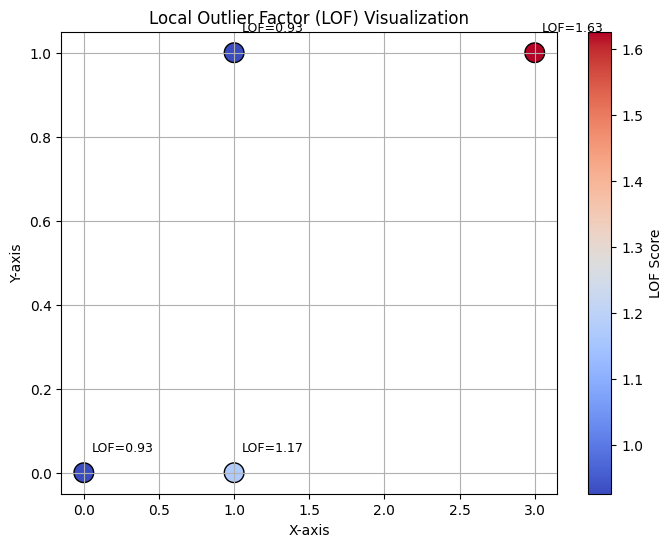

In [9]:
# Plotting the data points and LOF scores
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df['X'], df['Y'], c=lof_values, cmap='coolwarm', s=200, edgecolors='k')
plt.colorbar(scatter, label='LOF Score')
for i, (x, y, lof_val) in enumerate(zip(df['X'], df['Y'], df['LOF'])):
    plt.text(x + 0.05, y + 0.05, f'LOF={lof_val:.2f}', fontsize=9)

plt.title('Local Outlier Factor (LOF) Visualization')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.grid(True)
plt.show()